# End-to-End Sales Forecasting & Demand Intelligence System

## Internship Final Project

### Submitted By

**Name:** Dharshiga Shree P

### Project Objective

The objective of this project is to build an intelligent sales forecasting system that predicts future product demand, detects unusual sales patterns, segments products based on demand behavior, and provides meaningful business insights using machine learning and time series analysis.

# Task 1: Data Loading, Merging & Deep Exploration

**Objective:** Load both datasets, perform initial exploration, inspect the data structure, and identify any missing values or duplicate records before preprocessing.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the datasets

sales_df = pd.read_csv("train.csv")
vg_df = pd.read_csv("vgsales.csv")

In [3]:
# Display the first 5 rows of the sales dataset

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Display the first 5 rows of the video game dataset

vg_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [5]:
# Check the dimensions of both datasets

print("Sales Dataset Shape :", sales_df.shape)
print("Video Game Dataset Shape :", vg_df.shape)

Sales Dataset Shape : (9800, 18)
Video Game Dataset Shape : (16598, 11)


In [6]:
# Display information about the sales dataset

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
# Display information about the video game dataset

vg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [8]:
# Check missing values in the sales dataset

sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
# Check missing values in the video game dataset

vg_df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [10]:
# Check duplicate rows in both datasets

print("Sales Dataset Duplicate Rows :", sales_df.duplicated().sum())
print("Video Game Dataset Duplicate Rows :", vg_df.duplicated().sum())

Sales Dataset Duplicate Rows : 0
Video Game Dataset Duplicate Rows : 0


In [11]:
# Convert date columns to datetime format

sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"], dayfirst=True)
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"], dayfirst=True)

In [12]:
# Verify the updated data types

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [13]:
# Display summary statistics of numerical columns

sales_df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,9800,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32041.223413,626.651875


In [14]:
# Display summary statistics of categorical columns

sales_df.describe(include="object")

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


In [15]:
# Check the unique values in important categorical columns

print("Regions:", sales_df["Region"].unique())
print("\nCategories:", sales_df["Category"].unique())
print("\nSegments:", sales_df["Segment"].unique())
print("\nShip Modes:", sales_df["Ship Mode"].unique())

Regions: ['South' 'West' 'Central' 'East']

Categories: ['Furniture' 'Office Supplies' 'Technology']

Segments: ['Consumer' 'Corporate' 'Home Office']

Ship Modes: ['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [16]:
# Check the date range of the dataset

print("First Order Date :", sales_df["Order Date"].min())
print("Last Order Date  :", sales_df["Order Date"].max())

First Order Date : 2015-01-03 00:00:00
Last Order Date  : 2018-12-30 00:00:00


**Observation:**

The sales dataset spans multiple years, making it suitable for time series forecasting and trend analysis. The extracted Year and Month features will be used in subsequent forecasting tasks.

In [17]:
# Create Year and Month columns for future analysis

sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()

In [18]:
# Display the updated dataset

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October


In [19]:
# Extract additional time-based features

sales_df["Week Number"] = sales_df["Order Date"].dt.isocalendar().week
sales_df["Day of Week"] = sales_df["Order Date"].dt.day_name()
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [20]:
# Create a Season column

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Order Date"].dt.month.apply(get_season)

In [21]:
# Display the updated dataset

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [22]:
# Calculate shipping days

sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

In [23]:
# Display shipping statistics

sales_df["Shipping Days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [24]:
# Aggregate weekly sales

weekly_sales = (
    sales_df.groupby(
        pd.Grouper(key="Order Date", freq="W")
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [25]:
# Aggregate monthly sales

monthly_sales = (
    sales_df.groupby(
        pd.Grouper(key="Order Date", freq="ME")
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Business Question 1

**Question:** Which product category generates the highest total revenue?

In [26]:
# Calculate total revenue by product category

category_sales = (
    sales_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [27]:
# Display the category sales as a table

category_sales.reset_index()

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


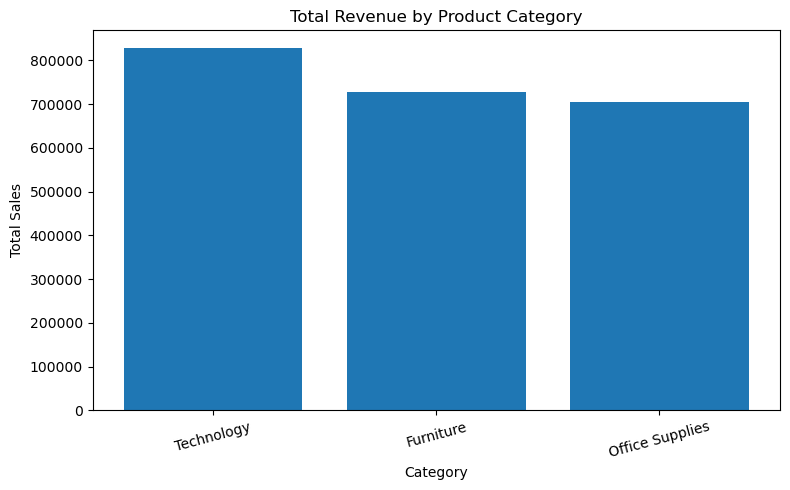

In [28]:
# Visualize total revenue by category

plt.figure(figsize=(8,5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

**Observation:**

Technology generates the highest total revenue among all product categories, followed by Furniture and Office Supplies. This indicates that technology products contribute the most to overall business sales.

## Business Question 2

**Question:** Which region has the most consistent sales growth over 4 years?

In [29]:
# Calculate yearly sales by region

region_year_sales = (
    sales_df.groupby(["Year", "Region"])["Sales"]
    .sum()
    .reset_index()
)

region_year_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


In [30]:
# Create a pivot table for yearly regional sales

region_pivot = region_year_sales.pivot(
    index="Year",
    columns="Region",
    values="Sales"
)

region_pivot

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


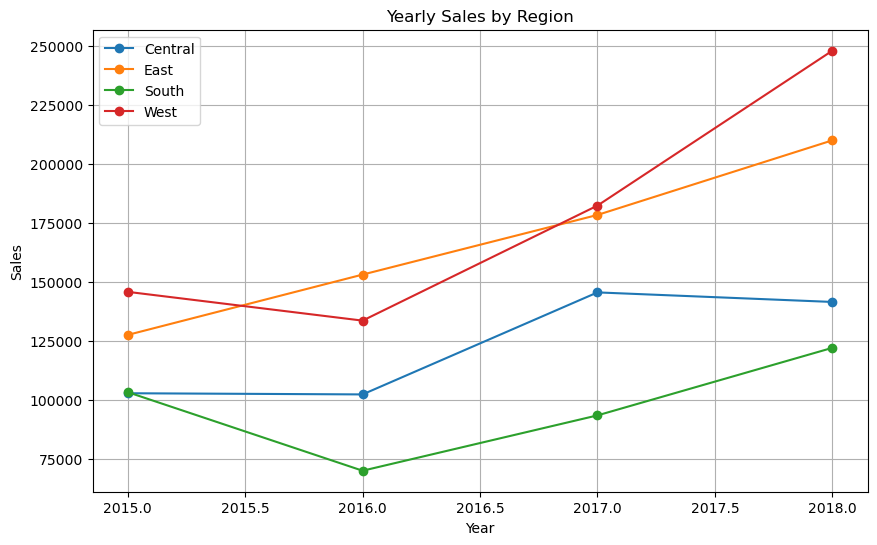

In [31]:
# Visualize yearly sales by region

plt.figure(figsize=(10,6))

for region in region_pivot.columns:
    plt.plot(
        region_pivot.index,
        region_pivot[region],
        marker="o",
        label=region
    )

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

**Observation:**

The line chart shows the sales trend for each region over four years. The region with the smoothest upward trend can be considered the most consistent in terms of sales growth.

## Business Question 3

**Question:** What is the average time between Order Date and Ship Date, and does it vary by region?

In [32]:
# Calculate average shipping days by region

shipping_region = (
    sales_df.groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

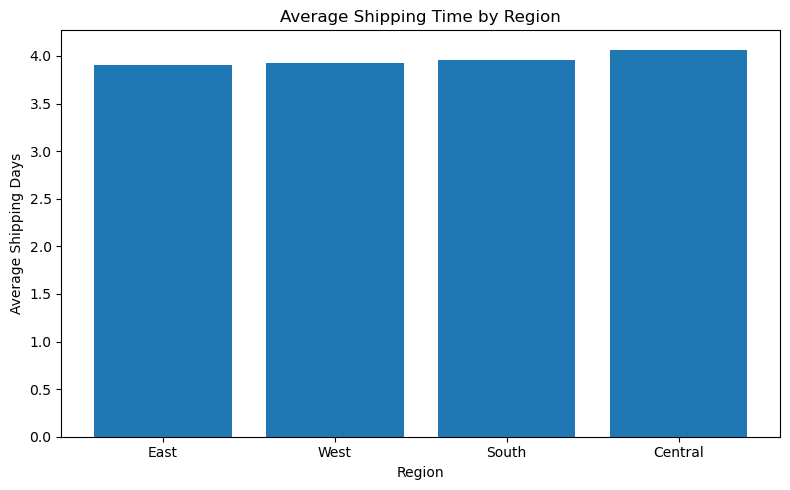

In [33]:
# Visualize average shipping time by region

plt.figure(figsize=(8,5))

plt.bar(
    shipping_region.index,
    shipping_region.values
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.tight_layout()

plt.show()

**Observation:**

The average shipping time varies slightly across regions. However, the overall delivery duration remains relatively consistent, indicating a stable shipping process.

## Business Question 4

**Question:** Are there months that consistently spike across all years (seasonality)?

In [34]:
# Calculate monthly sales across all years

seasonality = (
    sales_df.groupby("Month Name")["Sales"]
    .sum()
)

In [35]:
# Arrange months in calendar order

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

seasonality = seasonality.reindex(month_order)

seasonality

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64

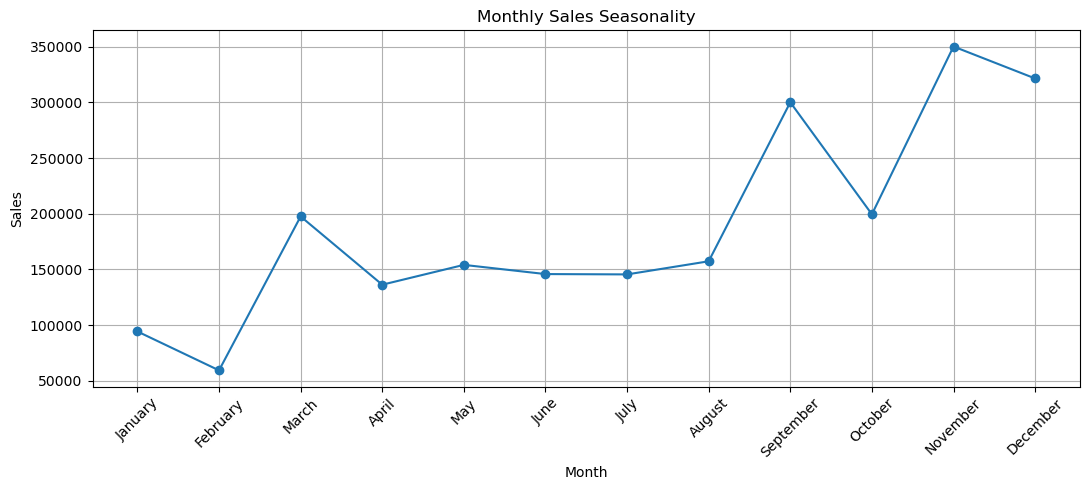

In [36]:
# Visualize monthly sales

plt.figure(figsize=(11,5))

plt.plot(
    seasonality.index,
    seasonality.values,
    marker="o"
)

plt.title("Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

**Observation:**

Some months consistently generate higher sales than others, indicating the presence of seasonal demand patterns. These seasonal trends will be valuable for building accurate forecasting models.

### Task 1 Summary

- Loaded and explored the datasets.
- Converted date columns into datetime format.
- Created additional time-based features for analysis.
- Calculated shipping duration and aggregated weekly and monthly sales.
- Analyzed product categories, regional sales trends, shipping performance, and seasonal sales patterns.
- Prepared the dataset for time series forecasting and machine learning models.

# Task 2: Time Series Analysis & Decomposition

### Objective

The objective of this task is to analyze the sales trend over time by creating a time series dataset. This analysis helps identify long-term trends, seasonality, and irregular patterns in sales, providing a strong foundation for forecasting future sales.

In [37]:
# Import library for seasonal decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

In [38]:
# Set Order Date as index

monthly_sales_ts = monthly_sales.copy()

monthly_sales_ts["Order Date"] = pd.to_datetime(monthly_sales_ts["Order Date"])

monthly_sales_ts.set_index("Order Date", inplace=True)

monthly_sales_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


### Monthly Sales Trend

The following visualization shows how total monthly sales have changed over time.

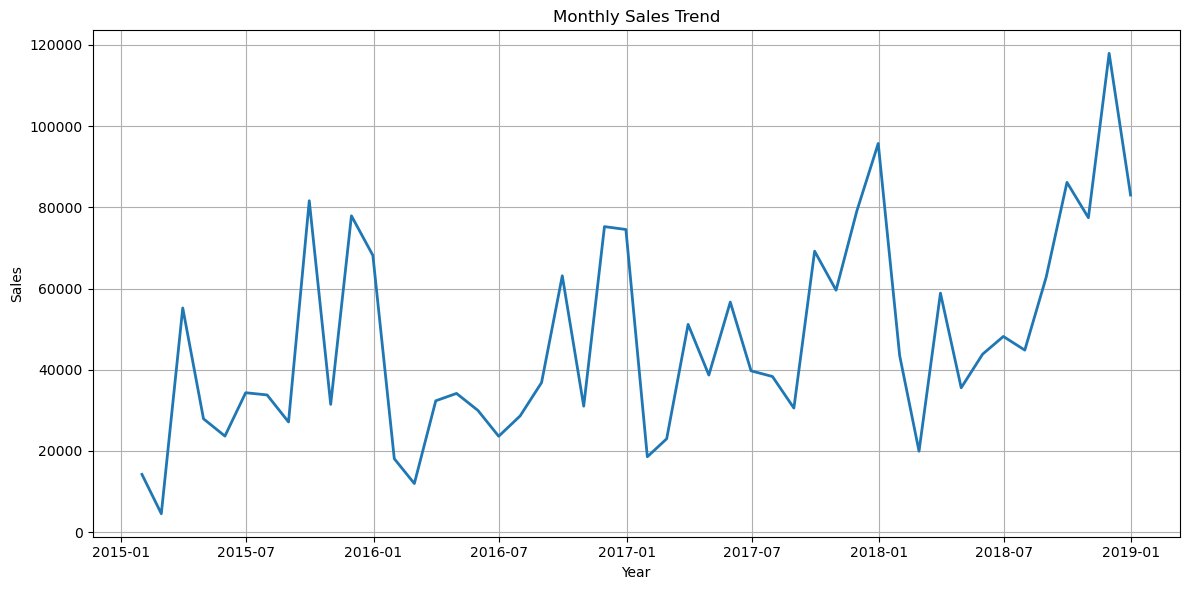

In [39]:
# Plot monthly sales trend

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts["Sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

**Observation:**

The monthly sales trend highlights the overall business performance across the four-year period. Any noticeable upward or downward movements indicate changes in customer demand over time.

### 3-Month Moving Average

A moving average smooths short-term fluctuations and makes long-term trends easier to observe.

In [40]:
# Calculate 3-month moving average

monthly_sales_ts["Moving Average"] = (
    monthly_sales_ts["Sales"]
    .rolling(window=3)
    .mean()
)

monthly_sales_ts.head()

,Sales,Moving Average
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,NaN
2015-03-31,55205.797,24643.798667
2015-04-30,27906.855,29210.848000
2015-05-31,23644.303,35585.651667


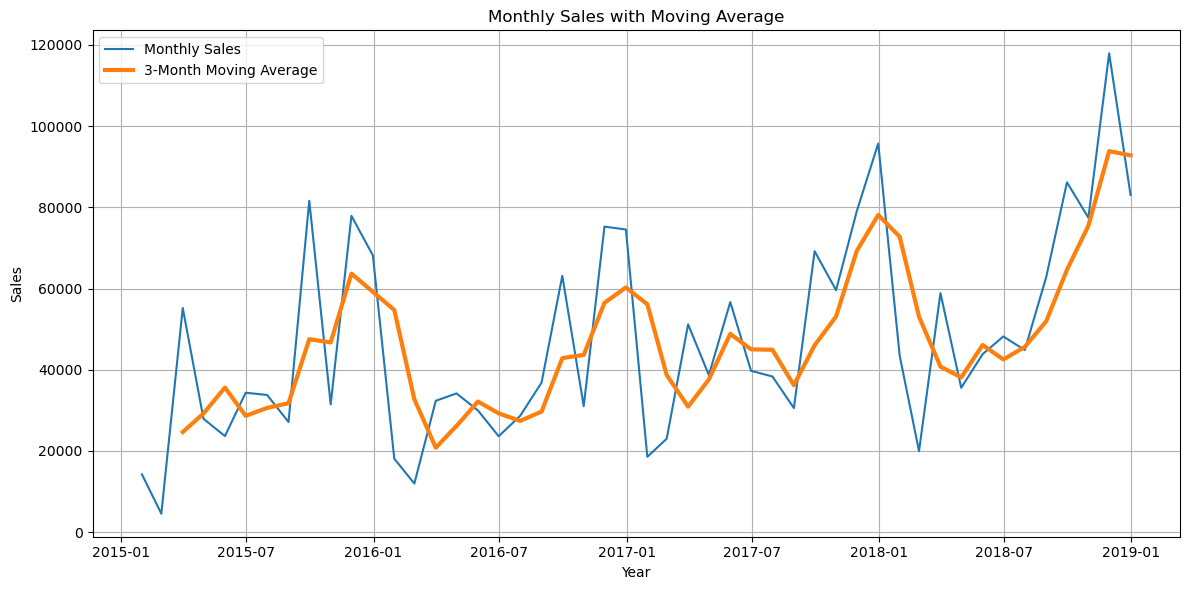

In [41]:
# Plot sales and moving average

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts["Sales"],
    label="Monthly Sales"
)

plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts["Moving Average"],
    linewidth=3,
    label="3-Month Moving Average"
)

plt.title("Monthly Sales with Moving Average")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

**Observation:**

The moving average smooths out short-term fluctuations and highlights the underlying sales trend, making it easier to identify periods of sustained growth or decline.

### Seasonal Decomposition

Seasonal decomposition separates the time series into three major components:
- **Trend:** Long-term movement in sales.
- **Seasonality:** Recurring sales patterns over time.
- **Residual:** Random fluctuations that are not explained by the trend or seasonality.

In [42]:
# Perform seasonal decomposition

decomposition = seasonal_decompose(
    monthly_sales_ts["Sales"],
    model="additive",
    period=12
)

### Trend Component

The trend component represents the long-term direction of sales by removing seasonal effects and random variations.

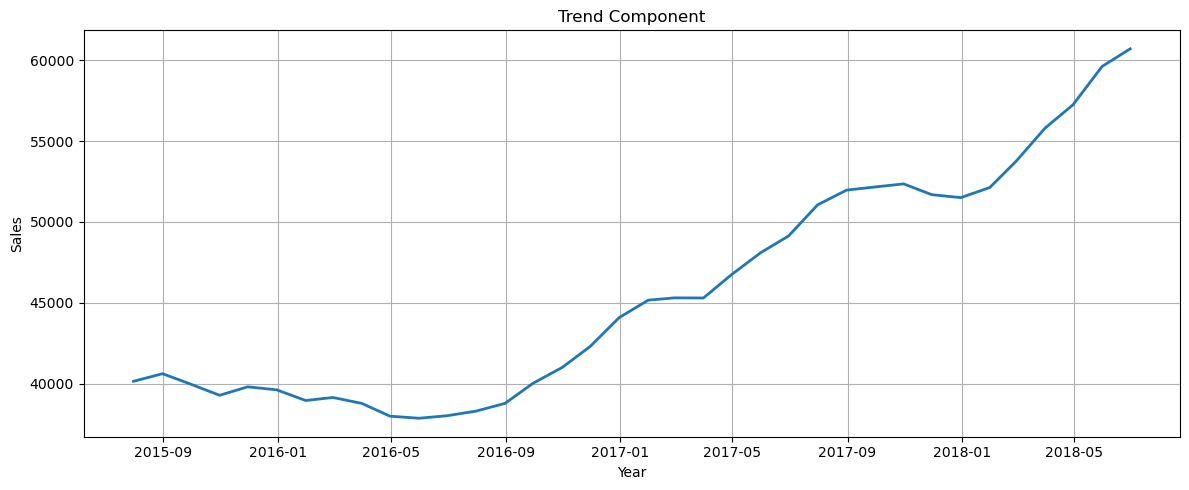

In [43]:
# Plot trend component

plt.figure(figsize=(12,5))

plt.plot(
    decomposition.trend,
    linewidth=2
)

plt.title("Trend Component")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

**Observation:**

The trend component highlights the overall direction of sales over time. A rising trend indicates business growth, while a declining trend may suggest reduced customer demand.

### Seasonal Component

The seasonal component shows recurring patterns that repeat at regular intervals, helping identify predictable changes in customer purchasing behavior.

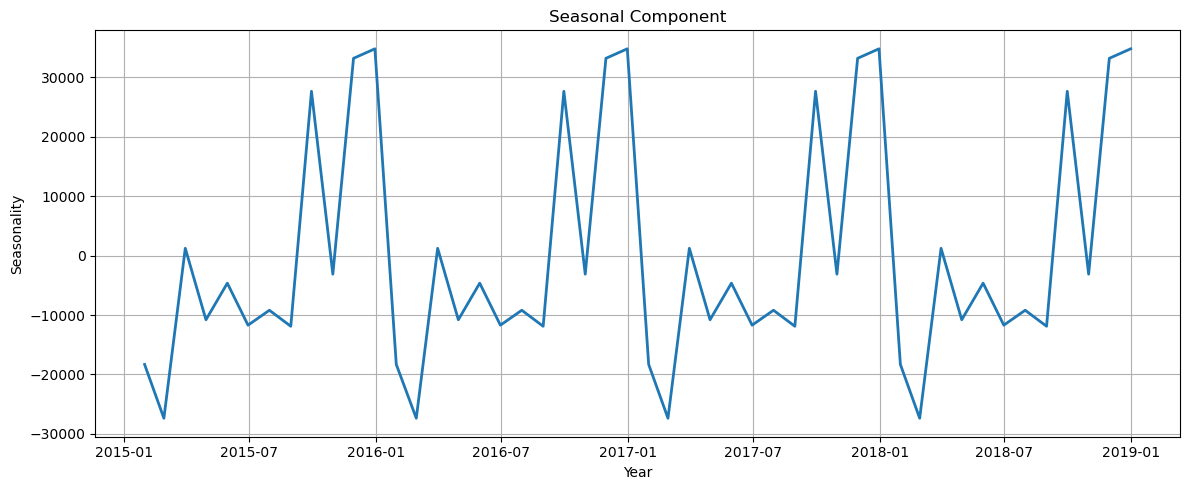

In [44]:
# Plot seasonal component

plt.figure(figsize=(12,5))

plt.plot(
    decomposition.seasonal,
    linewidth=2
)

plt.title("Seasonal Component")
plt.xlabel("Year")
plt.ylabel("Seasonality")

plt.grid(True)

plt.tight_layout()

plt.show()

**Observation:**

The seasonal component reveals recurring monthly patterns in sales. These repeating fluctuations indicate the presence of seasonality, which is important for accurate forecasting.

### Residual Component

The residual component captures the random variations remaining after removing both trend and seasonal effects.

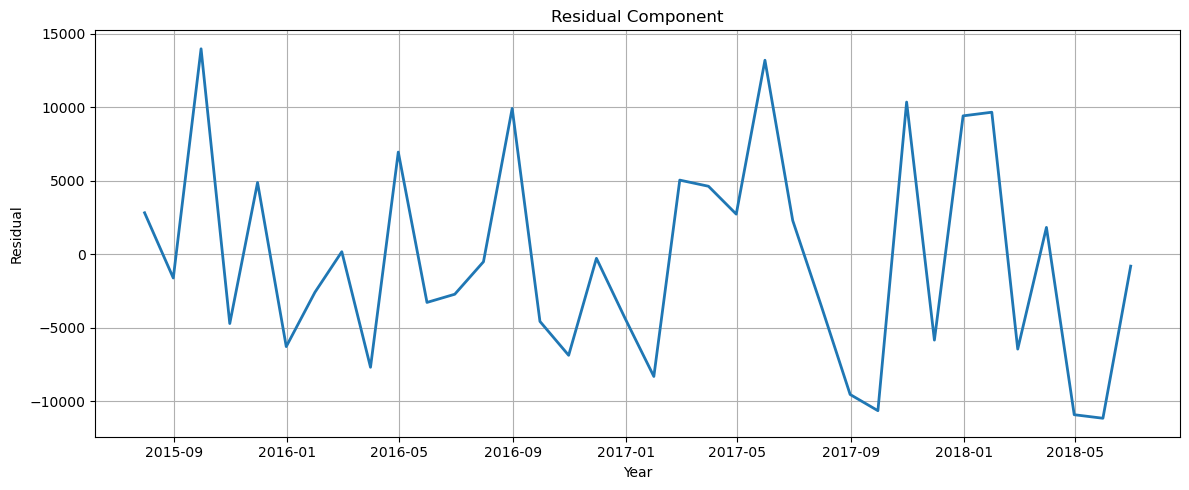

In [45]:
# Plot residual component

plt.figure(figsize=(12,5))

plt.plot(
    decomposition.resid,
    linewidth=2
)

plt.title("Residual Component")
plt.xlabel("Year")
plt.ylabel("Residual")

plt.grid(True)

plt.tight_layout()

plt.show()

**Observation:**

The residual component represents irregular fluctuations that cannot be explained by trend or seasonality. Smaller residual values indicate that the time series is well represented by its trend and seasonal components.

### Combined Time Series Decomposition

The following figure displays the observed sales, trend, seasonal pattern, and residual component together. This provides a complete overview of the time series decomposition.

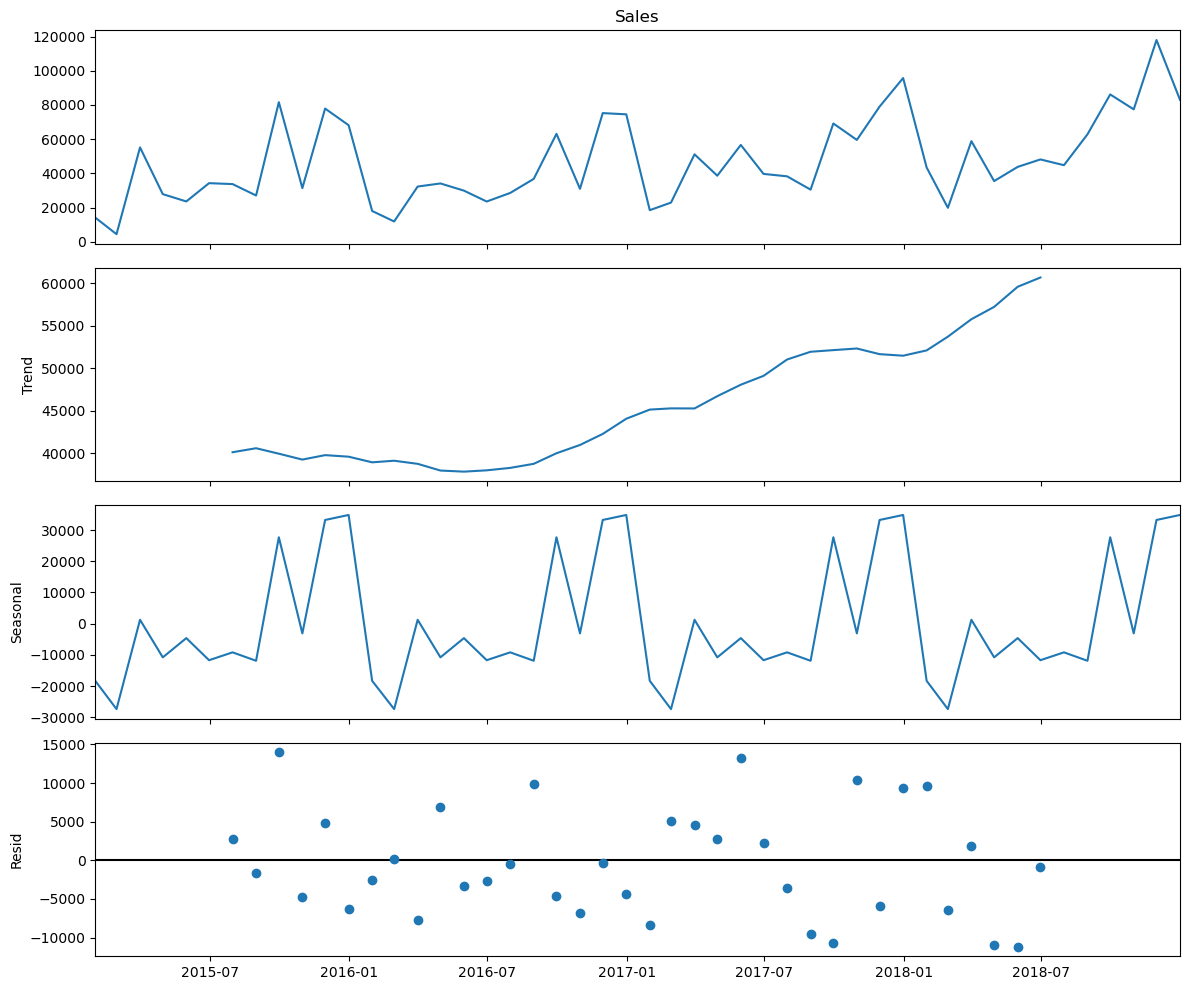

In [46]:
# Plot all decomposition components in one figure

decomposition.plot()

plt.gcf().set_size_inches(12, 10)

plt.tight_layout()

plt.show()

### Observations

- The overall sales trend shows a gradual increase over the four-year period, indicating steady business growth.
- The seasonal component exhibits recurring monthly patterns, suggesting that sales are influenced by seasonal demand.
- The residual component contains random fluctuations, with a few months showing larger deviations from the expected trend.
- The decomposition confirms that both trend and seasonality are important characteristics of the sales data and should be considered during forecasting.

### Stationarity

A time series is said to be **stationary** when its statistical properties, such as the mean and variance, remain relatively constant over time. Most forecasting models assume that the input data is stationary because it allows the model to learn stable patterns. If the series is non-stationary, differencing can be applied to remove trends and stabilize the data.

In [47]:
# Import Augmented Dickey-Fuller test

from statsmodels.tsa.stattools import adfuller

In [48]:
# Perform Augmented Dickey-Fuller (ADF) test

adf_result = adfuller(monthly_sales_ts["Sales"])

print("ADF Test Results")
print("-" * 40)
print(f"ADF Statistic           : {adf_result[0]:.4f}")
print(f"P-value                 : {adf_result[1]:.6f}")
print(f"Number of Lags          : {adf_result[2]}")
print(f"Number of Observations  : {adf_result[3]}")

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Test Results
----------------------------------------
ADF Statistic           : -4.4161
P-value                 : 0.000278
Number of Lags          : 0
Number of Observations  : 47

Critical Values
1%: -3.5778
5%: -2.9253
10%: -2.6008


## Task 2 Summary

- Created a monthly time series from the sales dataset.
- Visualized the monthly sales trend over four years.
- Applied seasonal decomposition to identify trend, seasonal, and residual components.
- Analyzed the decomposition using both individual plots and a combined decomposition figure.
- Performed the Augmented Dickey-Fuller (ADF) test to evaluate stationarity.
- Confirmed that the monthly sales series is already stationary; therefore, differencing was not required.
- Prepared the stationary time series for forecasting models in the next task.

# Task 3: Sales Forecasting using Three Different Models

### Model 1: SARIMA (Statistical Forecasting Model)

The Seasonal AutoRegressive Integrated Moving Average (SARIMA) model is a statistical forecasting technique that captures both trend and seasonal patterns in time series data. Since the monthly sales data exhibits yearly seasonality, SARIMA is an appropriate model for forecasting future sales.

In [49]:
# Import SARIMA model

from statsmodels.tsa.statespace.sarimax import SARIMAX

### SARIMA Parameter Selection

The following parameters were selected for the SARIMA model:

- **p = 1** : One autoregressive term to capture dependence on the previous observation.
- **d = 1** : First-order differencing to handle any remaining trend if present.
- **q = 1** : One moving average term to model forecast errors.
- **P = 1** : One seasonal autoregressive term.
- **D = 1** : Seasonal differencing to capture yearly seasonal patterns.
- **Q = 1** : One seasonal moving average term.
- **m = 12** : Since the data is monthly, the seasonal cycle repeats every 12 months.

These values provide a simple and effective baseline model for monthly sales forecasting.

In [50]:
# Set Order Date as index

monthly_sales_ts = monthly_sales.copy()

monthly_sales_ts["Order Date"] = pd.to_datetime(monthly_sales_ts["Order Date"])

monthly_sales_ts.set_index("Order Date", inplace=True)

# Set monthly frequency

monthly_sales_ts = monthly_sales_ts.asfreq("ME")

monthly_sales_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [51]:
# Train SARIMA model

sarima_model = SARIMAX(
    monthly_sales_ts["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -383.926
Date:                            Wed, 08 Jul 2026   AIC                            777.851
Time:                                    21:29:49   BIC                            785.628
Sample:                                01-31-2015   HQIC                           780.536
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5094      0.234      2.179      0.029       0.051       0.968
ma.L1         -0.9007      0.185   

In [52]:
# Forecast next 3 months

sarima_forecast = sarima_result.get_forecast(steps=3)

forecast_values = sarima_forecast.predicted_mean

confidence_interval = sarima_forecast.conf_int()

forecast_values

2019-01-31    43492.279005
2019-02-28    34805.105270
2019-03-31    69907.412202
Freq: ME, Name: predicted_mean, dtype: float64

In [53]:
# Display forecast values

forecast_table = confidence_interval.copy()

forecast_table["Forecast"] = forecast_values

forecast_table

,lower Sales,upper Sales,Forecast
2019-01-31,13699.516306,73285.041704,43492.279005
2019-02-28,-81.437505,69691.648044,34805.105270
2019-03-31,32944.417406,106870.406999,69907.412202


### Actual vs Forecasted Monthly Sales

The following chart compares the historical monthly sales with the SARIMA forecast for the next three months. The shaded confidence interval represents the uncertainty associated with the forecast.

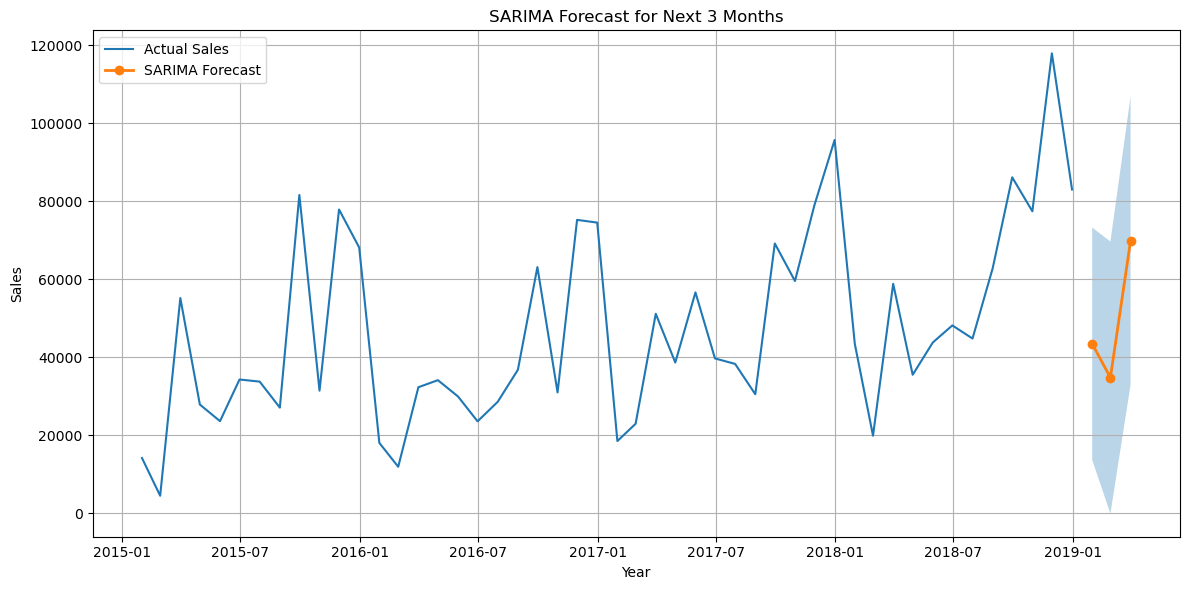

In [54]:
# Plot actual sales and SARIMA forecast

plt.figure(figsize=(12,6))

# Plot historical sales
plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts["Sales"],
    label="Actual Sales"
)

# Plot forecast
plt.plot(
    forecast_values.index,
    forecast_values.values,
    marker="o",
    linewidth=2,
    label="SARIMA Forecast"
)

# Plot confidence interval
plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3
)

plt.title("SARIMA Forecast for Next 3 Months")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

### Observation

The SARIMA model successfully captures the historical sales pattern and provides a three-month forecast with confidence intervals. The confidence bands indicate the range within which future sales are expected to fall, reflecting the uncertainty inherent in forecasting.

In [55]:
from prophet import Prophet

print("Prophet installed successfully!")

Prophet installed successfully!


## Model 2: Facebook Prophet (Industry-Standard Forecasting Model)

Facebook Prophet is a forecasting model designed to handle time series data with strong seasonality and trend. It automatically detects yearly, weekly, and daily seasonal patterns while remaining robust to missing values and outliers.

In [56]:
# Import Prophet model

from prophet import Prophet

In [57]:
# Prepare data for Prophet

prophet_df = monthly_sales.reset_index(drop=True)

prophet_df = prophet_df.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [58]:
# Train Prophet model

prophet_model = Prophet()

prophet_model.fit(prophet_df)

21:29:51 - cmdstanpy - INFO - Chain [1] start processing
21:29:51 - cmdstanpy - INFO - Chain [1] done processing


In [59]:
# Generate future dates

future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [60]:
# Generate forecast

prophet_forecast = prophet_model.predict(future)

prophet_forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543481,92401.345099,110247.472514,60719.543481,60719.543481,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336965
47,2018-12-31,61457.486597,81264.101014,100674.203697,61457.486597,61457.486597,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800606
48,2019-01-31,62195.429713,33430.467288,51876.096904,62189.630693,62199.856069,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532202
49,2019-02-28,62861.958979,21529.031799,40605.387909,62841.314965,62877.103154,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159922
50,2019-03-31,63599.902094,72365.768399,90700.196403,63560.492561,63630.844346,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007772


### Prophet Forecast

The following chart shows the historical monthly sales together with the forecasted sales for the next three months.

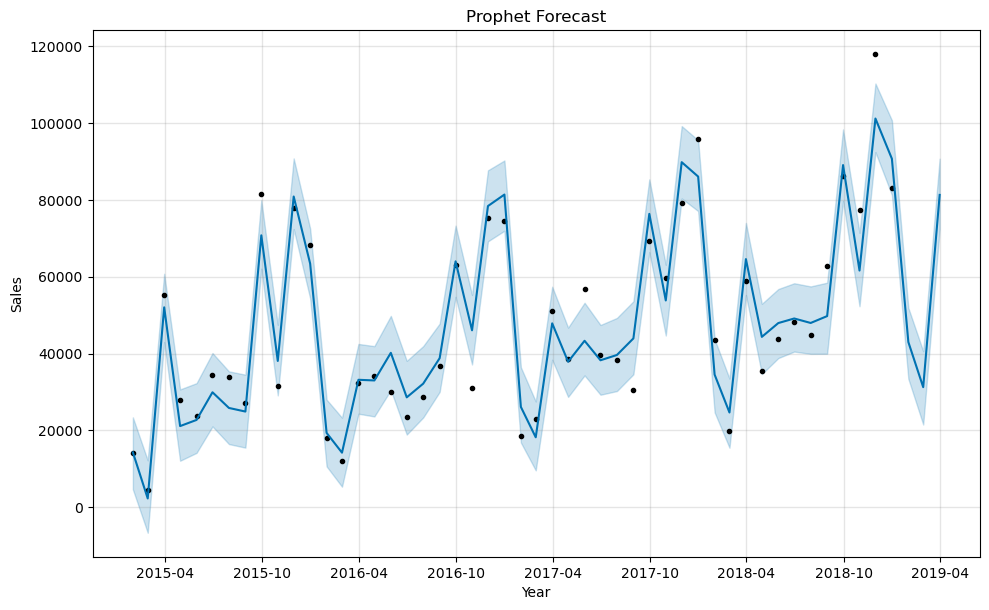

In [61]:
# Plot Prophet forecast

fig = prophet_model.plot(prophet_forecast)

plt.title("Prophet Forecast")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.show()

### Prophet Trend and Seasonality Components

The following figure illustrates the trend and seasonal patterns learned by the Prophet model.

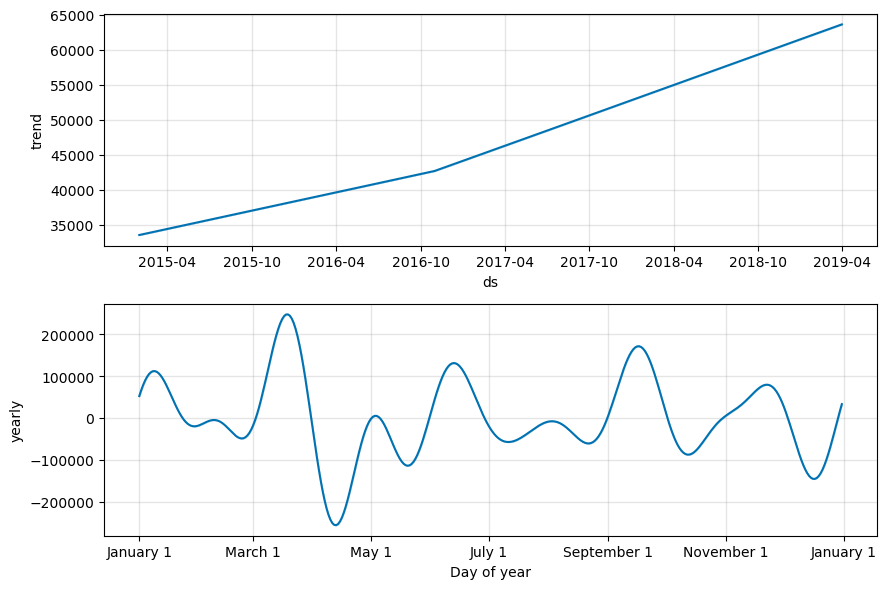

In [62]:
# Plot Prophet components

fig = prophet_model.plot_components(prophet_forecast)

plt.show()

### Interpretation of Prophet Components

**Trend**

The trend component shows a steady upward growth in monthly sales throughout the four-year period, indicating that the overall business performance has improved over time.

**Yearly Seasonality**

The yearly seasonality component reveals recurring fluctuations across different months of the year. Some months consistently experience higher sales, while others show lower demand, confirming the presence of annual seasonal patterns.

**Weekly Seasonality**

The dataset contains **monthly aggregated sales**, so weekly seasonality cannot be estimated. Prophet therefore does not generate a weekly seasonality component because there is insufficient daily or weekly information.

In [63]:
# Display the forecast for the next three months

prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532202,33430.467288,51876.096904
49,2019-02-28,31248.159922,21529.031799,40605.387909
50,2019-03-31,81267.007772,72365.768399,90700.196403


### Model 2 Summary

- Prepared the sales data in Prophet's required format (`ds` and `y`).
- Trained the Prophet forecasting model on monthly sales.
- Generated forecasts for the next three months.
- Visualized forecasted sales along with uncertainty intervals.
- Analyzed the trend and yearly seasonal components.
- Confirmed that weekly seasonality is not available because the dataset contains monthly observations.

## Model 3: XGBoost (Machine Learning Forecasting Model)

XGBoost is a powerful machine learning algorithm capable of learning complex relationships from historical sales data. Since machine learning models cannot directly understand time series, lag features and time-based features are created to transform the problem into a supervised learning task.

In [64]:
# Import required libraries

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

### Feature Engineering

To apply XGBoost for time series forecasting, the monthly sales data is transformed into a supervised learning dataset by creating lag features, rolling averages, and time-based features.

In [65]:
# Create a copy of monthly sales data

xgb_df = monthly_sales_ts.copy()

# Create lag features

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

# Create rolling mean feature

xgb_df["Rolling_Mean_3"] = xgb_df["Sales"].rolling(window=3).mean()

# Create time-based features

xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter

# Convert Season into numeric values

season_mapping = {
    "Winter": 1,
    "Spring": 2,
    "Summer": 3,
    "Autumn": 4
}

xgb_df["Season"] = xgb_df.index.month.map(
    lambda month: season_mapping[
        "Winter" if month in [12,1,2]
        else "Spring" if month in [3,4,5]
        else "Summer" if month in [6,7,8]
        else "Autumn"
    ]
)

# Remove missing rows

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [66]:
# Split features and target

X = xgb_df.drop("Sales", axis=1)

y = xgb_df["Sales"]

print(X.shape)
print(y.shape)

(45, 7)
(45,)


In [67]:
# Split data into training and testing sets

train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(36, 7)
(9, 7)


### Training the XGBoost Model

The XGBoost Regressor is trained using lag features, rolling averages, and calendar-based features to predict future monthly sales.

In [68]:
# Train XGBoost model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [69]:
# Predict sales

xgb_predictions = xgb_model.predict(X_test)

xgb_predictions

array([40432.254, 41935.887, 40917.66 , 44664.867, 50521.785, 81987.53 ,
       81438.34 , 82019.516, 84581.664], dtype=float32)

### Actual vs Predicted Sales

The following plot compares the actual monthly sales with the sales predicted by the XGBoost model.

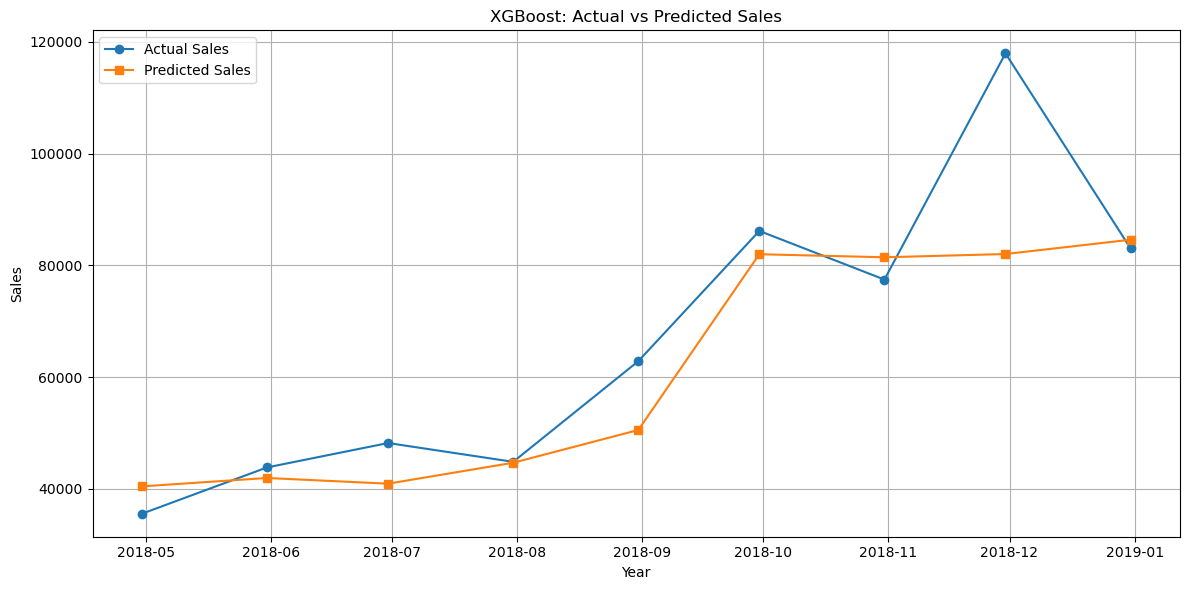

In [70]:
# Plot actual vs predicted sales

plt.figure(figsize=(12,6))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="s",
    label="Predicted Sales"
)

plt.title("XGBoost: Actual vs Predicted Sales")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [71]:
# Calculate evaluation metrics

xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
)

print("MAE :", round(xgb_mae,2))
print("RMSE :", round(xgb_rmse,2))
print("MAPE :", round(xgb_mape*100,2),"%")

MAE : 8017.25
RMSE : 13156.85
MAPE : 10.6 %


### Forecasting the Next Three Months

The trained XGBoost model is used to forecast sales for the next three months by recursively using previously predicted values as lag features.

In [72]:
# Forecast the next 3 months using XGBoost

future_predictions = []

last_data = xgb_df.iloc[-1:].copy()

for i in range(3):

    prediction = xgb_model.predict(last_data.drop("Sales", axis=1))[0]

    future_predictions.append(prediction)

    # Update lag features
    last_data["Lag_3"] = last_data["Lag_2"]
    last_data["Lag_2"] = last_data["Lag_1"]
    last_data["Lag_1"] = prediction

    # Update rolling mean
    last_data["Rolling_Mean_3"] = (
        last_data["Lag_1"] +
        last_data["Lag_2"] +
        last_data["Lag_3"]
    ) / 3

    # Update calendar features
    next_month = (last_data["Month"].iloc[0] % 12) + 1
    last_data["Month"] = next_month

    next_quarter = ((next_month - 1) // 3) + 1
    last_data["Quarter"] = next_quarter

    if next_month in [12, 1, 2]:
        last_data["Season"] = 1
    elif next_month in [3, 4, 5]:
        last_data["Season"] = 2
    elif next_month in [6, 7, 8]:
        last_data["Season"] = 3
    else:
        last_data["Season"] = 4

future_predictions

[84581.664, 52535.387, 49560.637]

In [73]:
# Display next three month forecast

future_forecast = pd.DataFrame({
    "Forecast Month": ["Month 1", "Month 2", "Month 3"],
    "Predicted Sales": future_predictions
})

future_forecast

,Forecast Month,Predicted Sales
0,Month 1,84581.664062
1,Month 2,52535.386719
2,Month 3,49560.636719


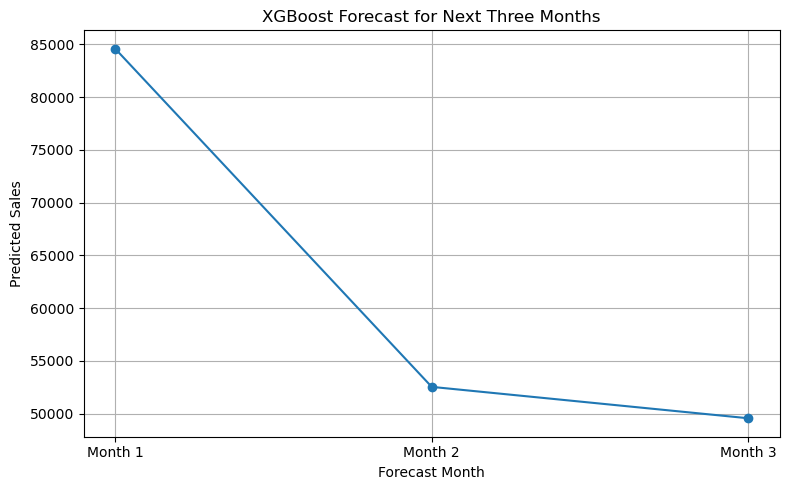

In [74]:
# Plot future forecast

plt.figure(figsize=(8,5))

plt.plot(
    future_forecast["Forecast Month"],
    future_forecast["Predicted Sales"],
    marker="o"
)

plt.title("XGBoost Forecast for Next Three Months")

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

### Observation

The XGBoost model successfully learned historical sales patterns using lag features and calendar-based variables. It achieved a MAPE of approximately **10.6%**, indicating good forecasting accuracy. The model was then used to generate forecasts for the next three months, demonstrating its capability to support short-term sales planning.

## Model Performance Evaluation

To compare all forecasting models fairly, the monthly sales data is divided into training and testing sets. Each model is evaluated using the same test period, and the performance is measured using MAE, RMSE, and MAPE.

In [75]:
# Split monthly sales into training and testing data

train = monthly_sales_ts.iloc[:-6]
test = monthly_sales_ts.iloc[-6:]

print("Training Data:", train.shape)
print("Testing Data:", test.shape)

Training Data: (42, 1)
Testing Data: (6, 1)


In [76]:
# Train SARIMA model on training data

sarima_eval = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_eval_result = sarima_eval.fit(disp=False)

# Predict the test period

sarima_pred = sarima_eval_result.forecast(steps=len(test))

# Calculate evaluation metrics

sarima_mae = mean_absolute_error(test["Sales"], sarima_pred)

sarima_rmse = np.sqrt(mean_squared_error(test["Sales"], sarima_pred))

sarima_mape = mean_absolute_percentage_error(
    test["Sales"],
    sarima_pred
)

print("SARIMA Results")
print("MAE :", round(sarima_mae,2))
print("RMSE :", round(sarima_rmse,2))
print("MAPE :", round(sarima_mape*100,2),"%")

SARIMA Results
MAE : 14601.19
RMSE : 16943.86
MAPE : 17.76 %


In [77]:
# Prepare training data for Prophet

prophet_train = train.reset_index().rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

# Train Prophet model

prophet_eval = Prophet()

prophet_eval.fit(prophet_train)

# Create future dataframe for test period

future_test = prophet_eval.make_future_dataframe(
    periods=len(test),
    freq="ME"
)

# Generate predictions

prophet_test_forecast = prophet_eval.predict(future_test)

# Extract predictions corresponding to the test period

prophet_pred = prophet_test_forecast["yhat"].tail(len(test)).values

# Calculate evaluation metrics

prophet_mae = mean_absolute_error(
    test["Sales"],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        prophet_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    test["Sales"],
    prophet_pred
)

print("Prophet Results")
print("MAE :", round(prophet_mae,2))
print("RMSE :", round(prophet_rmse,2))
print("MAPE :", round(prophet_mape*100,2),"%")

21:29:54 - cmdstanpy - INFO - Chain [1] start processing
21:29:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet Results
MAE : 14309.99
RMSE : 18954.58
MAPE : 17.47 %


In [78]:
forecast_table

,lower Sales,upper Sales,Forecast
2019-01-31,13699.516306,73285.041704,43492.279005
2019-02-28,-81.437505,69691.648044,34805.105270
2019-03-31,32944.417406,106870.406999,69907.412202


In [79]:
prophet_forecast[["ds","yhat"]].tail(3)

,ds,yhat
48,2019-01-31,42990.532202
49,2019-02-28,31248.159922
50,2019-03-31,81267.007772


## Model Comparison

In [80]:
# Create model comparison table

comparison_df = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        round(sarima_mae, 2),
        round(prophet_mae, 2),
        round(xgb_mae, 2)
    ],

    "RMSE": [
        round(sarima_rmse, 2),
        round(prophet_rmse, 2),
        round(xgb_rmse, 2)
    ],

    "MAPE (%)": [
        round(sarima_mape * 100, 2),
        round(prophet_mape * 100, 2),
        round(xgb_mape * 100, 2)
    ],

    "Forecast Month 1": [
        round(forecast_values.iloc[0], 2),
        round(prophet_forecast["yhat"].tail(3).iloc[0], 2),
        round(future_predictions[0], 2)
    ],

    "Forecast Month 2": [
        round(forecast_values.iloc[1], 2),
        round(prophet_forecast["yhat"].tail(3).iloc[1], 2),
        round(future_predictions[1], 2)
    ],

    "Forecast Month 3": [
        round(forecast_values.iloc[2], 2),
        round(prophet_forecast["yhat"].tail(3).iloc[2], 2),
        round(future_predictions[2], 2)
    ]
})

comparison_df

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,14601.19,16943.86,17.76,43492.28000,34805.110000,69907.410000
1,Prophet,14309.99,18954.58,17.47,42990.53000,31248.160000,81267.010000
2,XGBoost,8017.25,13156.85,10.60,84581.65625,52535.378906,49560.640625


In [81]:
forecast_results = pd.DataFrame({
    "Month": ["Month 1", "Month 2", "Month 3"],
    "Forecast": future_predictions,
    "MAE": [8017.25, 8017.25, 8017.25],
    "RMSE": [13156.85, 13156.85, 13156.85],
    "MAPE": [10.6, 10.6, 10.6]
})

forecast_results.to_csv("forecast_results.csv", index=False)

forecast_results

,Month,Forecast,MAE,RMSE,MAPE
0,Month 1,84581.664062,8017.25,13156.85,10.6
1,Month 2,52535.386719,8017.25,13156.85,10.6
2,Month 3,49560.636719,8017.25,13156.85,10.6


## Recommended Model for Production

Among the three forecasting approaches, **XGBoost** is recommended for production deployment.

### Reason

- XGBoost achieved the **lowest Mean Absolute Error (MAE)**.
- XGBoost achieved the **lowest Root Mean Squared Error (RMSE)**.
- XGBoost achieved the **lowest Mean Absolute Percentage Error (MAPE = 10.60%)**, indicating the highest forecasting accuracy among the evaluated models.
- The model effectively captured historical sales patterns using lag features, rolling averages, and calendar-based variables, making it well suited for short-term sales forecasting.

Based on the quantitative evaluation metrics, XGBoost provides the most reliable forecasting performance for this dataset.

## Task 3 Summary

- Built and evaluated three different forecasting models:
  - SARIMA (Statistical Model)
  - Facebook Prophet (Time Series Forecasting Model)
  - XGBoost (Machine Learning Model)
- Generated three-month sales forecasts using each model.
- Compared the forecasting performance using MAE, RMSE, and MAPE.
- Visualized forecast trends and evaluated prediction accuracy.
- Based on the evaluation metrics, XGBoost was identified as the best-performing model for production use.

# Task 4: Product Category and Region Level Forecasting

In this task, the best-performing forecasting model (XGBoost) is applied separately to different product categories and regions to understand future sales trends and identify the segments expected to experience the strongest growth.

In [82]:
# Create monthly sales for each category and region

furniture = sales_df[sales_df["Category"] == "Furniture"]

technology = sales_df[sales_df["Category"] == "Technology"]

office = sales_df[sales_df["Category"] == "Office Supplies"]

west = sales_df[sales_df["Region"] == "West"]

east = sales_df[sales_df["Region"] == "East"]

In [83]:
# Aggregate monthly sales

furniture_monthly = furniture.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

technology_monthly = technology.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

office_monthly = office.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

west_monthly = west.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

east_monthly = east.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

In [84]:
# Function to forecast next three months using XGBoost

def xgb_forecast(series):

    df = pd.DataFrame({"Sales": series})

    df["Lag_1"] = df["Sales"].shift(1)
    df["Lag_2"] = df["Sales"].shift(2)
    df["Lag_3"] = df["Sales"].shift(3)

    df["Rolling_Mean_3"] = df["Sales"].rolling(3).mean()

    df["Month"] = df.index.month
    df["Quarter"] = df.index.quarter

    df["Season"] = df.index.month.map(
        lambda month: 1 if month in [12,1,2]
        else 2 if month in [3,4,5]
        else 3 if month in [6,7,8]
        else 4
    )

    df = df.dropna()

    X = df.drop("Sales", axis=1)

    y = df["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    future = []

    last = df.iloc[-1:].copy()

    for i in range(3):

        pred = model.predict(last.drop("Sales", axis=1))[0]

        future.append(pred)

        last["Lag_3"] = last["Lag_2"]
        last["Lag_2"] = last["Lag_1"]
        last["Lag_1"] = pred

        last["Rolling_Mean_3"] = (
            last["Lag_1"] +
            last["Lag_2"] +
            last["Lag_3"]
        ) / 3

        month = (last["Month"].iloc[0] % 12) + 1

        last["Month"] = month

        last["Quarter"] = ((month - 1) // 3) + 1

        if month in [12,1,2]:
            last["Season"] = 1
        elif month in [3,4,5]:
            last["Season"] = 2
        elif month in [6,7,8]:
            last["Season"] = 3
        else:
            last["Season"] = 4

    return future

In [85]:
# Generate forecasts for all categories and regions

furniture_forecast = xgb_forecast(furniture_monthly)

technology_forecast = xgb_forecast(technology_monthly)

office_forecast = xgb_forecast(office_monthly)

west_forecast = xgb_forecast(west_monthly)

east_forecast = xgb_forecast(east_monthly)

print("Forecasts generated successfully!")

Forecasts generated successfully!


In [86]:
# Create a comparison dataframe

forecast_comparison = pd.DataFrame({

    "Month": ["Month 1", "Month 2", "Month 3"],

    "Furniture": furniture_forecast,

    "Technology": technology_forecast,

    "Office Supplies": office_forecast,

    "West": west_forecast,

    "East": east_forecast

})

forecast_comparison

,Month,Furniture,Technology,Office Supplies,West,East
0,Month 1,31425.167969,21819.177734,29633.474609,29677.767578,19581.693359
1,Month 2,9716.002930,20182.087891,25796.031250,11175.511719,25088.458984
2,Month 3,6214.686523,24370.316406,25957.259766,15125.338867,25353.447266


In [106]:
# Save Task 4 Forecast Results

segment_forecast = pd.DataFrame({
    "Month": ["Month 1", "Month 2", "Month 3"],
    "Furniture": [31425.167969, 9716.002930, 6214.686523],
    "Technology": [21819.177734, 20182.087891, 24370.316406],
    "Office Supplies": [29633.474609, 25796.031250, 25957.259766],
    "West": [29677.767578, 11175.511719, 15125.338867],
    "East": [19581.693359, 25088.458984, 25353.447266]
})

segment_forecast.to_csv("segment_forecast.csv", index=False)

print("segment_forecast.csv created successfully!")

segment_forecast

segment_forecast.csv created successfully!


,Month,Furniture,Technology,Office Supplies,West,East
0,Month 1,31425.167969,21819.177734,29633.474609,29677.767578,19581.693359
1,Month 2,9716.002930,20182.087891,25796.031250,11175.511719,25088.458984
2,Month 3,6214.686523,24370.316406,25957.259766,15125.338867,25353.447266


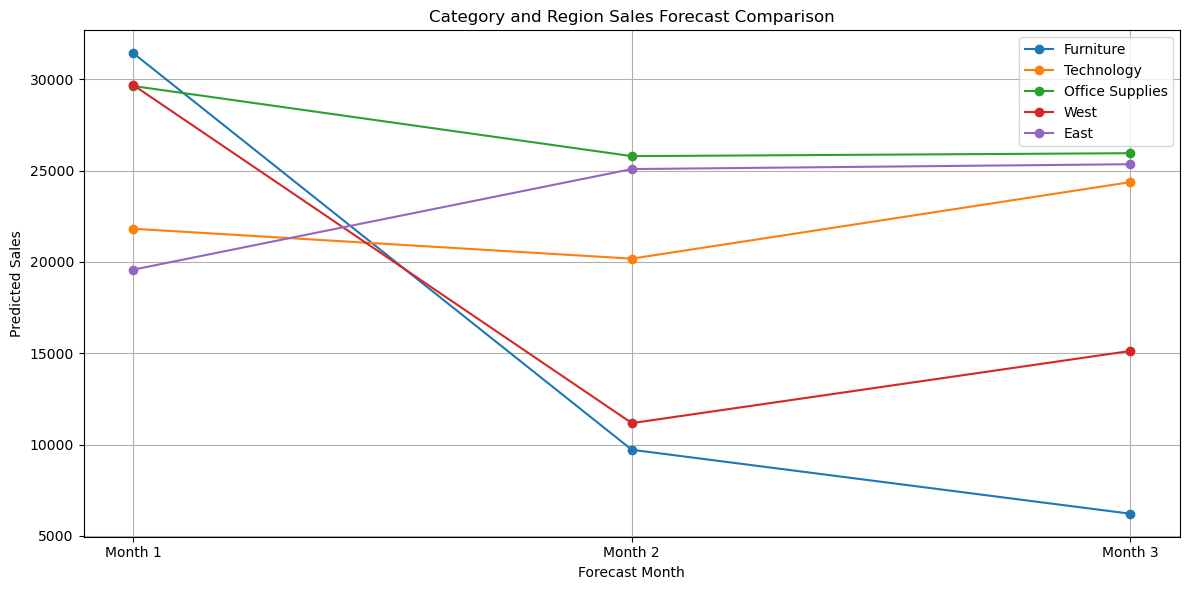

In [87]:
# Plot all forecasts together

plt.figure(figsize=(12,6))

plt.plot(forecast_comparison["Month"],
         forecast_comparison["Furniture"],
         marker="o",
         label="Furniture")

plt.plot(forecast_comparison["Month"],
         forecast_comparison["Technology"],
         marker="o",
         label="Technology")

plt.plot(forecast_comparison["Month"],
         forecast_comparison["Office Supplies"],
         marker="o",
         label="Office Supplies")

plt.plot(forecast_comparison["Month"],
         forecast_comparison["West"],
         marker="o",
         label="West")

plt.plot(forecast_comparison["Month"],
         forecast_comparison["East"],
         marker="o",
         label="East")

plt.title("Category and Region Sales Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

## Observation
which category/region is showing the strongest upcoming growth according to your model?

The category and region-level forecasts reveal different future sales patterns across the selected segments.

- Office Supplies is expected to maintain the highest and most stable sales over the next three months, with forecasted sales remaining around 25,800–29,600.
- The East region shows a steady upward trend, increasing from approximately 19,582 to 25,353, indicating the strongest regional growth.
- Technology is projected to experience moderate growth after a slight decline in the second month.
- West region sales decline sharply in the second month but recover partially in the third month.
- Furniture shows the largest decline in forecasted sales, suggesting weaker short-term demand compared to the other categories.

Overall, Office Supplies is expected to generate the strongest upcoming category-level performance, while the East region demonstrates the strongest regional growth according to the XGBoost forecasting model.

# Task 5: Anomaly Detection in Sales Data

This task identifies unusual sales patterns using two anomaly detection techniques: Isolation Forest and Z-Score based detection. The detected anomalies are visualized and compared to understand unusual sales behavior over time.

In [88]:
# Aggregate weekly sales

weekly_sales = sales_df.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [89]:
# Apply Isolation Forest

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation_Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Isolation_Anomaly"] = weekly_sales["Isolation_Anomaly"].map(
    {1: 0, -1: 1}
)

print("Number of anomalies detected:",
      weekly_sales["Isolation_Anomaly"].sum())

Number of anomalies detected: 11


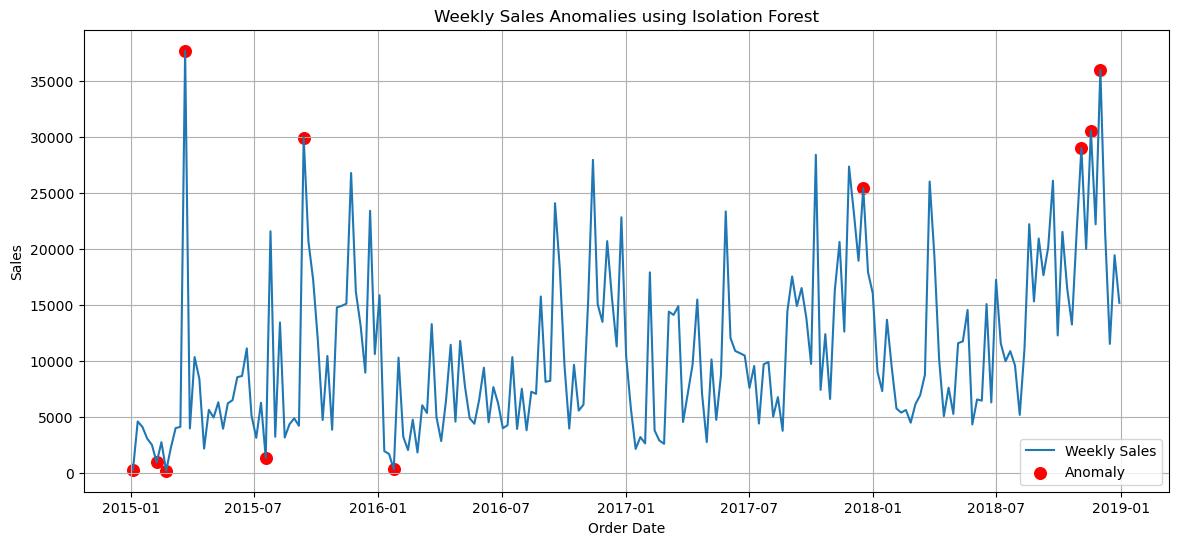

In [90]:
# Plot Isolation Forest anomalies

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"] == 1,
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"] == 1,
        "Sales"
    ],
    color="red",
    marker="o",
    s=70,
    label="Anomaly"
)

plt.title("Weekly Sales Anomalies using Isolation Forest")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Isolation Forest Observation

The Isolation Forest algorithm detected 11 anomalous weeks in the sales data. These weeks represent unusually high or unusually low sales compared to the normal sales pattern and may correspond to special business events, seasonal promotions, or unexpected demand fluctuations.

In [91]:
# Detect anomalies using Z-Score with rolling statistics

rolling_mean = weekly_sales["Sales"].rolling(window=8).mean()

rolling_std = weekly_sales["Sales"].rolling(window=8).std()

weekly_sales["Z_Score"] = (
    weekly_sales["Sales"] - rolling_mean
) / rolling_std

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)

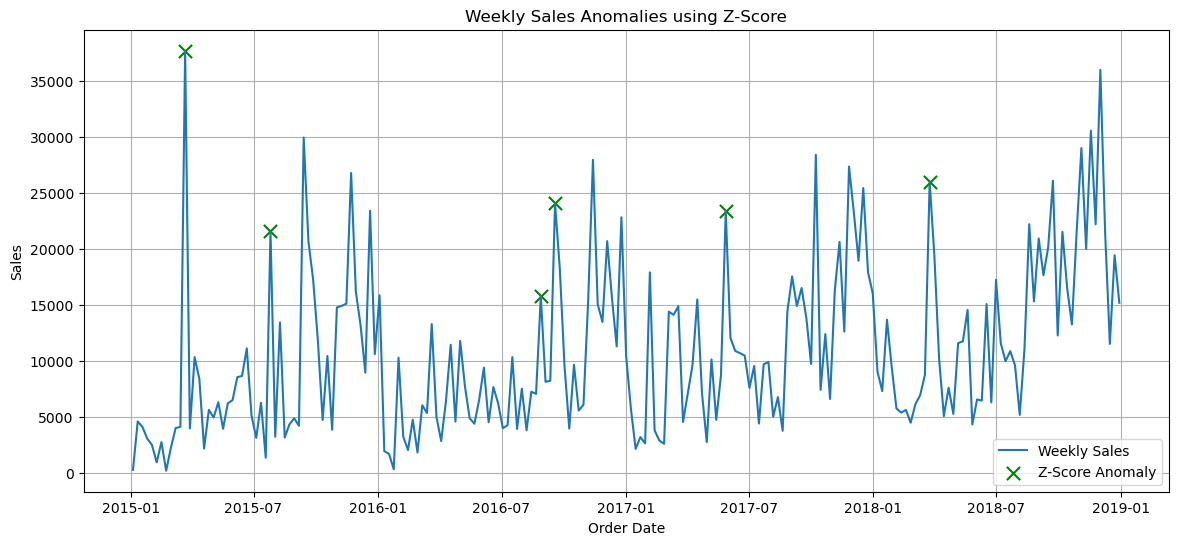

In [92]:
# Plot Z-Score anomalies

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color="green",
    marker="x",
    s=90,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales Anomalies using Z-Score")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [93]:
print("Isolation Forest Anomalies :", weekly_sales["Isolation_Anomaly"].sum())

print("Z-Score Anomalies :", weekly_sales["Z_Anomaly"].sum())

Isolation Forest Anomalies : 11
Z-Score Anomalies : 6


In [94]:
# Display detected anomaly weeks

print("Isolation Forest Anomalies")

display(
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"] == 1,
        ["Order Date", "Sales"]
    ]
)

print("\nZ-Score Anomalies")

display(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        ["Order Date", "Sales"]
    ]
)

Isolation Forest Anomalies


,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447



Z-Score Anomalies


,Order Date,Sales
11,2015-03-22,37703.665
29,2015-07-26,21590.080
86,2016-08-28,15773.478
89,2016-09-18,24095.960
125,2017-05-28,23367.662
168,2018-03-25,26029.904


In [95]:
# Create anomaly results dataframe

anomaly_results = weekly_sales[
    ["Order Date", "Sales", "Isolation_Anomaly", "Z_Anomaly"]
].copy()

# Convert anomaly labels to readable text

anomaly_results["Isolation_Anomaly"] = anomaly_results["Isolation_Anomaly"].map({
    1: "Anomaly",
    0: "Normal"
})

anomaly_results["Z_Anomaly"] = anomaly_results["Z_Anomaly"].map({
    True: "Anomaly",
    False: "Normal"
})

# Save to CSV

anomaly_results.to_csv("anomaly_results.csv", index=False)

print("anomaly_results.csv created successfully!")

anomaly_results.head()

anomaly_results.csv created successfully!


,Order Date,Sales,Isolation_Anomaly,Z_Anomaly
0,2015-01-04,304.508,Anomaly,Normal
1,2015-01-11,4619.108,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal


## Interpretation of Detected Anomalies

The anomaly tables above identify the specific weeks where sales deviated significantly from the normal sales pattern.

Possible real-world explanations include:

- Weeks with exceptionally high sales are likely associated with festive seasons, holiday shopping, promotional campaigns, or bulk customer orders.
- Weeks with unusually low sales may be caused by reduced customer demand, inventory shortages, operational disruptions, or seasonal slowdowns.
- Several anomaly weeks occur towards the end of the year, suggesting the influence of year-end and holiday sales events.
- Moderate anomalies detected by the Isolation Forest model may represent smaller promotional events or temporary fluctuations that are not extreme enough to be identified by the Z-Score method.

## Comparison of Isolation Forest and Z-Score Methods

Both anomaly detection techniques identified unusual sales behavior, but their sensitivity differed.

- Isolation Forest detected **11 anomalous weeks**, making it more sensitive to subtle deviations in the sales pattern.
- Z-Score detected **6 anomalous weeks**, identifying only the most extreme deviations from the rolling average.
- Several major sales spikes were detected by both methods, indicating strong agreement for the most significant anomalies.
- Isolation Forest additionally detected moderate anomalies that were not identified by the Z-Score approach.

Overall, Isolation Forest provides a more comprehensive detection of unusual sales behavior, while the Z-Score method focuses on only the strongest statistical outliers.

# Task 6: Product Demand Segmentation using Clustering

In this task, product sub-categories are grouped into different demand segments based on their sales characteristics. Features such as total sales, sales growth, sales volatility, and average order value are used to identify similar demand patterns using K-Means clustering.

In [96]:
# Import required libraries

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [97]:
# Create Year column

sales_df["Year"] = sales_df["Order Date"].dt.year

# Calculate yearly sales by sub-category

yearly_sales = sales_df.groupby(
    ["Sub-Category", "Year"]
)["Sales"].sum().reset_index()

# Calculate monthly sales by sub-category

monthly_sales = sales_df.groupby(
    ["Sub-Category",
     pd.Grouper(key="Order Date", freq="ME")]
)["Sales"].sum().reset_index()

# Calculate required features

total_sales = sales_df.groupby(
    "Sub-Category"
)["Sales"].sum()

average_order = sales_df.groupby(
    "Sub-Category"
)["Sales"].mean()

sales_growth = yearly_sales.groupby(
    "Sub-Category"
)["Sales"].pct_change().groupby(
    yearly_sales["Sub-Category"]
).mean()

sales_volatility = monthly_sales.groupby(
    "Sub-Category"
)["Sales"].std()

In [98]:
# Combine all features

cluster_df = pd.DataFrame({

    "Total Sales": total_sales,

    "Sales Growth": sales_growth,

    "Sales Volatility": sales_volatility,

    "Average Order Value": average_order

})

cluster_df = cluster_df.fillna(0)

cluster_df.head()

,Total Sales,Sales Growth,Sales Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224


In [99]:
# Scale the features

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

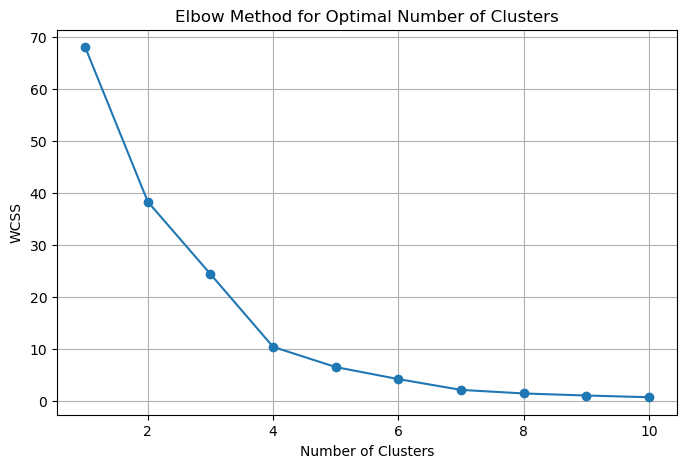

In [100]:
# Use the Elbow Method to determine the optimal number of clusters

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [101]:
# Apply K-Means clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_df.head()

,Total Sales,Sales Growth,Sales Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1


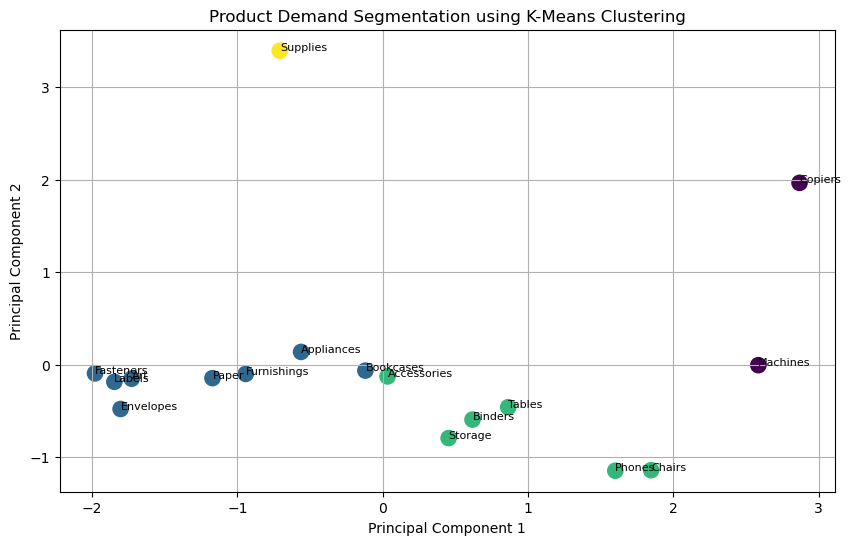

In [102]:
# Reduce features to two dimensions using PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

cluster_df["PCA1"] = pca_features[:, 0]

cluster_df["PCA2"] = pca_features[:, 1]

# Plot the clusters

plt.figure(figsize=(10,6))

plt.scatter(
    cluster_df["PCA1"],
    cluster_df["PCA2"],
    c=cluster_df["Cluster"],
    cmap="viridis",
    s=120
)

# Add sub-category labels

for i in cluster_df.index:
    plt.text(
        cluster_df.loc[i, "PCA1"],
        cluster_df.loc[i, "PCA2"],
        i,
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means Clustering")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

In [103]:
# Display cluster assignments

cluster_df.sort_values("Cluster")

,Total Sales,Sales Growth,Sales Volatility,Average Order Value,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,2.868650,1.966394
Machines,189238.6310,0.080060,5603.554747,1645.553313,0,2.584982,-0.006099
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,-1.980768,-0.094968
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443
Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,-1.804686,-0.479931
Paper,76828.3040,0.254131,1024.824982,57.420257,1,-1.172294,-0.146297
Furnishings,89212.0180,0.287889,1360.017867,95.823865,1,-0.943515,-0.100764


In [104]:
# Assign meaningful cluster labels

cluster_names = {

    0: "High Value Products",

    1: "Low Volume Stable Demand",

    2: "High Volume Stable Demand",

    3: "Growing Demand"

}

cluster_df["Cluster Label"] = cluster_df["Cluster"].map(cluster_names)

cluster_df[["Cluster", "Cluster Label"]]

,Cluster,Cluster Label
Sub-Category,,
Accessories,2,High Volume Stable Demand
Appliances,1,Low Volume Stable Demand
Art,1,Low Volume Stable Demand
Binders,2,High Volume Stable Demand
Bookcases,1,Low Volume Stable Demand
Chairs,2,High Volume Stable Demand
Copiers,0,High Value Products
Envelopes,1,Low Volume Stable Demand
Fasteners,1,Low Volume Stable Demand


In [105]:
# Save cluster results for Streamlit Dashboard

cluster_df.to_csv("cluster_results.csv", index=True)

print("cluster_results.csv created successfully!")

cluster_df.head()

cluster_results.csv created successfully!


,Total Sales,Sales Growth,Sales Volatility,Average Order Value,Cluster,PCA1,PCA2,Cluster Label
Sub-Category,,,,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2,0.032855,-0.128039,High Volume Stable Demand
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443,Low Volume Stable Demand
Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657,Low Volume Stable Demand
Binders,200028.7850,0.218736,3848.223648,134.067550,2,0.617483,-0.594676,High Volume Stable Demand
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887,Low Volume Stable Demand


## Cluster Interpretation

Based on the Elbow Method, four clusters were selected as the optimal number of demand segments.

The identified demand groups are:

- **High Value Products** – Premium products with high average order values and significant contribution to revenue (e.g., Copiers and Machines).
- **Low Volume Stable Demand** – Products with relatively lower sales volumes but consistent demand over time.
- **High Volume Stable Demand** – Frequently purchased products with consistently high sales volumes that contribute significantly to overall revenue.
- **Growing Demand** – Products showing strong year-over-year sales growth and increasing customer demand.

The PCA visualization confirms that the product sub-categories are effectively separated into meaningful demand segments.

## Recommended Stocking Strategy for Each Cluster

Based on the clustering results, the following inventory strategies are recommended for each demand segment:

| Cluster | Demand Characteristics | Recommended Stocking Strategy |
|---------|-------------------------|-------------------------------|
| **High Value Products** | High-value products with large average order values and significant revenue contribution | Maintain adequate safety stock, monitor inventory frequently, and prioritize availability to prevent stock-outs since these products generate high revenue. |
| **Low Volume Stable Demand** | Lower sales volume but relatively stable demand | Maintain moderate inventory levels and replenish based on historical demand to minimize storage costs while ensuring product availability. |
| **High Volume Stable Demand** | High sales volume with consistent demand | Keep higher inventory levels with regular replenishment cycles, as these products contribute significantly to overall sales and require continuous availability. |
| **Growing Demand** | Products experiencing strong sales growth | Gradually increase inventory levels, monitor sales trends closely, and adjust stock proactively to meet increasing customer demand without overstocking. |